
# **K-Nearest Neighbors (KNN) — Essential Notes and Codes**

K-Nearest Neighbors (KNN) is a **supervised machine learning algorithm** used for **classification and regression**.

The idea is simple:

When a new data point appears, the algorithm looks at the **K closest data points** in the training dataset and assigns the class based on the **majority vote**.



## **1. Distance Metric**

KNN determines neighbors using a **distance metric**.

Most commonly used distance:

### Euclidean Distance

$$
d(x,y) = \sqrt{\sum (x_i - y_i)^2}
$$

Where

- $x$ = query point
- $y$ = training sample



## **2. Creating a Sample Dataset**


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)



## **3. Train Test Split**


In [2]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## **4. Feature Scaling**

KNN is sensitive to feature scale, so we apply **standardization**.


In [3]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



## **5. Training a KNN Model**


In [4]:

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)


KNeighborsClassifier()


## **6. Making Predictions**


In [5]:

y_pred = model.predict(X_test)



## **7. Model Evaluation**

In [6]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.93
Confusion Matrix
[[47  3]
 [ 4 46]]
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        50
           1       0.94      0.92      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100




## **8. Choosing the Best K**

Choosing the correct value of **K** is important.

Too small K → Overfitting  
Too large K → Underfitting


In [7]:

from sklearn.metrics import accuracy_score

k_values = range(1,21)
scores = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    scores.append(accuracy_score(y_test, y_pred))

print(scores)


[0.93, 0.94, 0.93, 0.93, 0.93, 0.94, 0.93, 0.93, 0.92, 0.92, 0.92, 0.93, 0.92, 0.9, 0.91, 0.91, 0.91, 0.91, 0.9, 0.9]



## **9. Plotting Accuracy vs K**


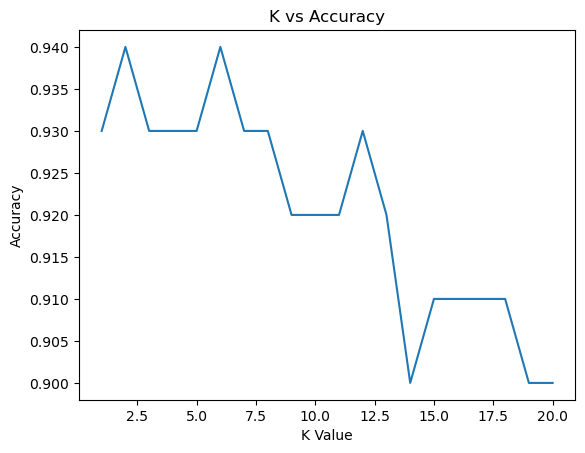

In [8]:

plt.plot(k_values, scores)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()



## **10. Important KNN Parameters**

Important hyperparameters:

- **n_neighbors** → number of neighbors
- **metric** → distance metric
- **weights** → uniform or distance
- **algorithm** → auto, kd_tree, ball_tree
